In [1]:
"""
Customer Churn Regression Analysis
===================================
Dataset: Synthetic Customer Behavior and Churn Dataset (15,000 records)
Author:  Business Data Analyst
Date:    2026-02-19

Sections:
    1. Data Loading & Exploration
    2. Feature Engineering
    3. Logistic Regression (statsmodels – for regression table)
    4. Logistic Regression (sklearn – for predictive metrics)
    5. Visualizations
    6. Summary Statistics
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
import warnings
warnings.filterwarnings('ignore')

# ── Visual Settings ───────────────────────────────────────────────────────
PRIMARY = "#1C4B82"; ACCENT = "#E84A5F"; LIGHT = "#A8C5E8"
DARK    = "#1A1A2E"
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.family": "DejaVu Sans",
                     "axes.spines.top": False, "axes.spines.right": False})
OUTPUT_DIR = "./"   # Change to save charts elsewhere


# Step 1: Load the dataset
df = pd.read_csv("synthetic_customer_behavior_and_churn.csv")

# Step 2: Data Overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nDescriptive Statistics:\n{df.describe().round(2)}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Step 3: Churn Distribution
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100
print(f"\nChurn Distribution:")
print(f"  Retained (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"  Churned  (1): {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")

# Note: From here, you can follow the other sections of your script to continue with feature engineering,
# logistic regression, and visualizations.

DATASET OVERVIEW
Shape: (15000, 21)

Data Types:
customer_id                      object
signup_date                      object
tenure_months                     int64
age                               int64
gender                           object
region                           object
income_level                     object
subscription_type                object
monthly_charges                 float64
total_charges                   float64
usage_frequency                  object
avg_session_duration_minutes    float64
number_of_logins_per_month        int64
number_of_support_tickets         int64
satisfaction_score                int64
payment_method                   object
contract_type                    object
last_login_days_ago               int64
promotional_response             object
discount_used                    object
churn                             int64
dtype: object

Descriptive Statistics:
       tenure_months       age  monthly_charges  total_charges  \
count 

In [2]:
# ════════════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════════════════
df_model = df.copy()
df_model.describe()

,tenure_months,age,monthly_charges,total_charges,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,last_login_days_ago,churn
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000
mean,17.448467,41.646933,59.046174,978.208528,45.235633,18.519600,2.927133,3.38440,21.748533,0.318867
std,10.304214,11.740994,32.996490,864.474724,29.244734,12.335911,2.609012,1.24951,22.282570,0.466053
min,1.000000,18.000000,19.990000,16.500000,5.000000,1.000000,0.000000,1.00000,0.000000,0.000000
25%,8.000000,33.000000,31.640000,351.145000,21.900000,9.000000,1.000000,3.00000,5.000000,0.000000
50%,17.000000,42.000000,55.150000,735.260000,40.500000,16.000000,2.000000,4.00000,13.000000,0.000000
75%,26.000000,50.000000,73.742500,1372.332500,58.500000,24.000000,4.000000,4.00000,32.000000,1.000000
max,35.000000,80.000000,149.950000,5506.350000,119.900000,49.000000,11.000000,5.00000,89.000000,1.000000


In [5]:
usage_map = {'low': 0, 'medium': 1, 'high': 2}
df_model['usage_frequency']        = df_model['usage_frequency'].map(usage_map)
df_model['promo_response_encoded'] = (df_model['promotional_response'] == 'yes').astype(int)
df_model['discount_used_encoded']  = (df_model['discount_used'] == 'yes').astype(int)
df_model['income_encoded']         = df_model['income_level'].map({'low':0,'medium':1,'high':2})
df_model['sub_encoded']            = df_model['subscription_type'].map({'basic':0,'standard':1,'premium':2})
df_model['contract_encoded']       = df_model['contract_type'].map({'monthly':0,'yearly':1})

In [6]:
feature_cols = [
    'age', 'tenure_months', 'monthly_charges', 'usage_frequency',
    'avg_session_duration_minutes', 'number_of_logins_per_month',
    'number_of_support_tickets', 'satisfaction_score',
    'last_login_days_ago', 'promo_response_encoded',
    'discount_used_encoded', 'income_encoded', 'sub_encoded', 'contract_encoded'
]

# ════════════════════════════════════════════════════════════════════════
# 3. LOGISTIC REGRESSION – statsmodels (for regression table with p-values)
# ════════════════════════════════════════════════════════════════════════
X_sm       = df_model[feature_cols].copy().astype(float)
y_sm       = df_model['churn'].astype(float)
X_sm_const = sm.add_constant(X_sm)
sm_model   = Logit(y_sm, X_sm_const).fit(maxiter=200, disp=False)

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION RESULTS (statsmodels)")
print("=" * 60)
print(sm_model.summary2())

results = sm_model.summary2().tables[1].copy()
results.columns = ['Coef', 'Std Err', 'z', 'P>|z|', '[0.025', '0.975]']
results['Odds Ratio'] = np.exp(results['Coef'])
results['Significance'] = results['P>|z|'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.')

print("\nRegression Table with Odds Ratios:")
print(results[['Coef', 'Std Err', 'z', 'P>|z|', 'Odds Ratio', 'Significance']].round(4).to_string())
print(f"\nModel Fit Statistics:")
print(f"  McFadden Pseudo-R²: {sm_model.prsquared:.4f}")
print(f"  Log-Likelihood:     {sm_model.llf:.2f}")
print(f"  AIC:                {sm_model.aic:.2f}")
print(f"  BIC:                {sm_model.bic:.2f}")
print(f"  LLR p-value:        {sm_model.llr_pvalue:.4e}")
print(f"  Observations:       {int(sm_model.nobs):,}")


LOGISTIC REGRESSION RESULTS (statsmodels)
                               Results: Logit
Model:                   Logit                Method:               MLE      
Dependent Variable:      churn                Pseudo R-squared:     0.692    
Date:                    2026-02-19 19:20     AIC:                  5812.3951
No. Observations:        15000                BIC:                  5926.6322
Df Model:                14                   Log-Likelihood:       -2891.2  
Df Residuals:            14985                LL-Null:              -9390.2  
Converged:               1.0000               LLR p-value:          0.0000   
No. Iterations:          8.0000               Scale:                1.0000   
-----------------------------------------------------------------------------
                              Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------------
const                         1.1046   0.2248   4.913

In [7]:
# ════════════════════════════════════════════════════════════════════════
# 4. LOGISTIC REGRESSION – sklearn (for classification metrics)
# ════════════════════════════════════════════════════════════════════════
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_sm)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_sm, test_size=0.2, random_state=42, stratify=y_sm)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred  = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n" + "=" * 60)
print("PREDICTIVE MODEL PERFORMANCE (sklearn, 80/20 split)")
print("=" * 60)
print(f"  Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"  ROC-AUC:   {auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Retained','Churned'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")


PREDICTIVE MODEL PERFORMANCE (sklearn, 80/20 split)
  Accuracy:  0.9163 (91.6%)
  ROC-AUC:   0.9733

Classification Report:
              precision    recall  f1-score   support

    Retained       0.95      0.92      0.94      2043
     Churned       0.84      0.90      0.87       957

    accuracy                           0.92      3000
   macro avg       0.90      0.91      0.91      3000
weighted avg       0.92      0.92      0.92      3000

Confusion Matrix:
[[1884  159]
 [  92  865]]



GENERATING VISUALIZATIONS...


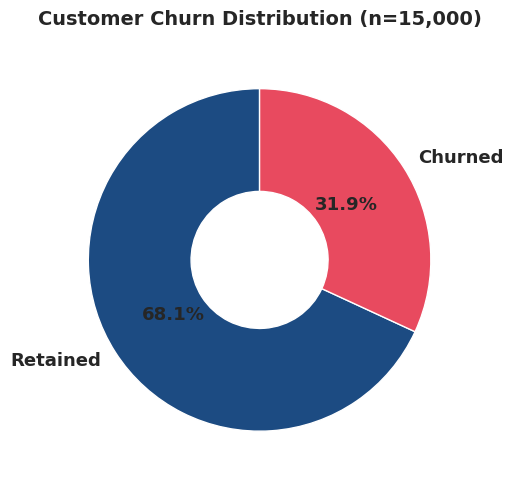

In [12]:
# To ensure visualizations are displayed inline in the Jupyter Notebook
%matplotlib inline

import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════
# 5. VISUALIZATIONS
# ════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS...")
print("=" * 60)

# Chart 1: Churn Distribution Donut
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie([churn_pct[0], churn_pct[1]], labels=['Retained', 'Churned'],
       colors=[PRIMARY, ACCENT], autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(width=0.6), textprops={'fontsize': 13, 'fontweight': 'bold'})
ax.set_title('Customer Churn Distribution (n=15,000)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Display the plot inline
plt.show()

# Optional: Uncomment the following line if you want to save the figure
# plt.savefig(f"{OUTPUT_DIR}chart_churn_dist.png", dpi=150, bbox_inches='tight'); plt.close()

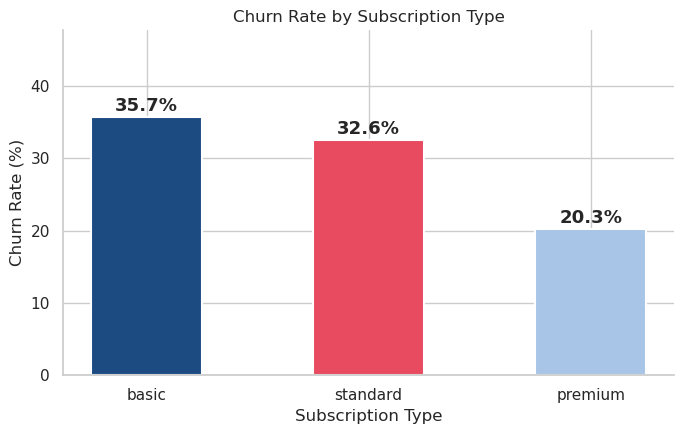

In [13]:
# Ensure visualizations are displayed inline in the Jupyter Notebook
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have your DataFrame `df` and color variables defined as PRIMARY, ACCENT, LIGHT
# Chart 2: Churn Rate by Subscription Type
churn_sub = df.groupby('subscription_type')['churn'].mean().reset_index()
churn_sub['Rate'] = churn_sub['churn'] * 100
churn_sub['subscription_type'] = pd.Categorical(churn_sub['subscription_type'],
    categories=['basic', 'standard', 'premium'], ordered=True)
churn_sub = churn_sub.sort_values('subscription_type')

# Create a bar chart for churn rate by subscription type
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(churn_sub['subscription_type'], churn_sub['Rate'],
              color=[PRIMARY, ACCENT, LIGHT], edgecolor='white', linewidth=1.5, width=0.5)

# Annotate each bar with the churn rate value
for bar, val in zip(bars, churn_sub['Rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

# Set labels and title
ax.set(xlabel='Subscription Type', ylabel='Churn Rate (%)',
       title='Churn Rate by Subscription Type', ylim=(0, churn_sub['Rate'].max() + 12))

plt.tight_layout()

# Display the plot inline
plt.show()

# Optional: Uncomment to save the figure
# plt.savefig(f"{OUTPUT_DIR}chart_churn_by_sub.png", dpi=150, bbox_inches='tight'); plt.close()

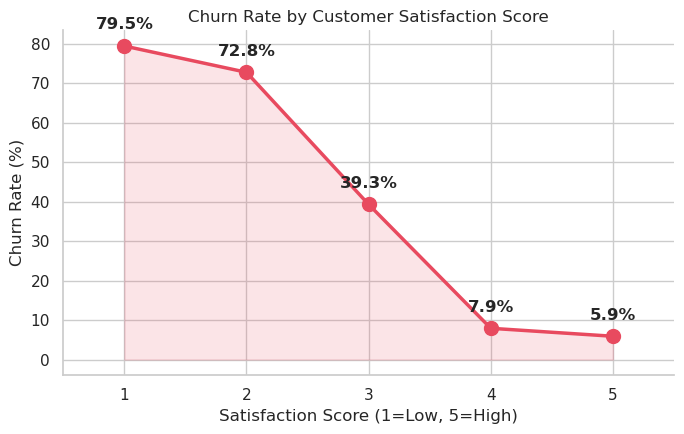

In [15]:
# Ensure visualizations are displayed inline in the Jupyter Notebook
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have your DataFrame `df` and the color variable defined as ACCENT
# Chart 3: Churn by Satisfaction Score
churn_sat = df.groupby('satisfaction_score')['churn'].mean().reset_index()
churn_sat['Rate'] = churn_sat['churn'] * 100

# Create a line plot for churn rate by satisfaction score
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(churn_sat['satisfaction_score'], churn_sat['Rate'], marker='o',
        markersize=10, linewidth=2.5, color=ACCENT)
ax.fill_between(churn_sat['satisfaction_score'], churn_sat['Rate'], alpha=0.15, color=ACCENT)

# Annotate each point with the churn rate value
for _, row in churn_sat.iterrows():
    ax.annotate(f"{row['Rate']:.1f}%", (row['satisfaction_score'], row['Rate']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=12, fontweight='bold')

# Set labels and title
ax.set(xlabel='Satisfaction Score (1=Low, 5=High)', ylabel='Churn Rate (%)',
       title='Churn Rate by Customer Satisfaction Score', xticks=[1, 2, 3, 4, 5], xlim=(0.5, 5.5))

plt.tight_layout()

# Display the plot inline
plt.show()

# Optional: Uncomment to save the figure
# plt.savefig(f"{OUTPUT_DIR}chart_churn_by_satisfaction.png", dpi=150, bbox_inches='tight'); plt.close()

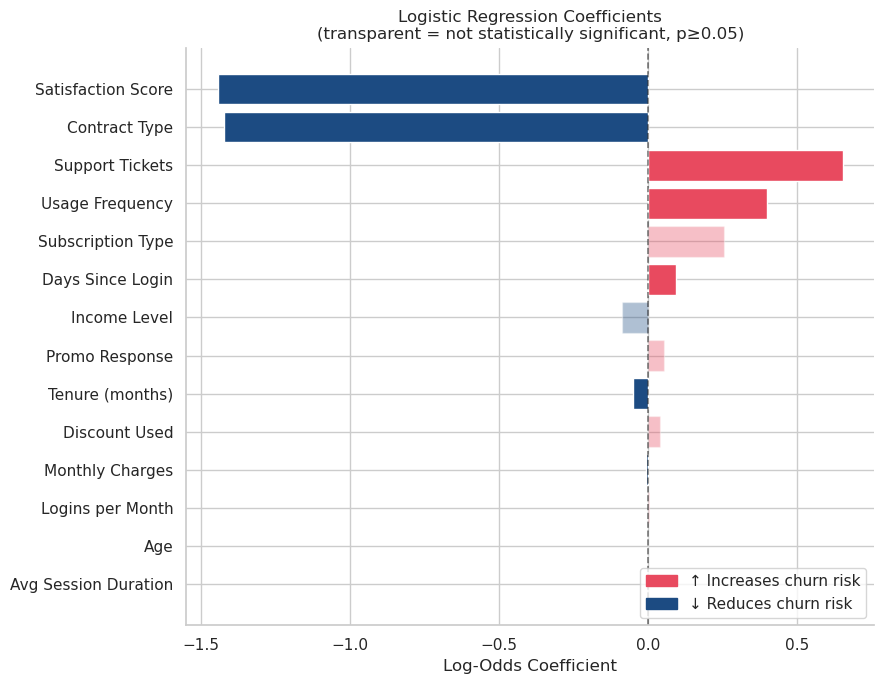

In [16]:
# Ensure visualizations are displayed inline in the Jupyter Notebook
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Assuming you have a fitted `sm_model` and color variables defined
# Chart 4: Coefficient Plot
coef_df = pd.DataFrame({
    'Feature': ['Age', 'Tenure (months)', 'Monthly Charges', 'Usage Frequency',
                'Avg Session Duration', 'Logins per Month', 'Support Tickets',
                'Satisfaction Score', 'Days Since Login', 'Promo Response',
                'Discount Used', 'Income Level', 'Subscription Type', 'Contract Type'],
    'Coefficient': sm_model.params[1:].values,
    'P_value': sm_model.pvalues[1:].values
}).sort_values('Coefficient', key=abs, ascending=True)

# Create a horizontal bar plot for coefficients
fig, ax = plt.subplots(figsize=(9, 7))
for _, row in coef_df.iterrows():
    color = ACCENT if row['Coefficient'] > 0 else PRIMARY
    alpha = 1.0 if row['P_value'] < 0.05 else 0.35
    ax.barh(row['Feature'], row['Coefficient'], color=color, alpha=alpha, edgecolor='white')

# Add a vertical line at x=0
ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)

# Set labels and title
ax.set(xlabel='Log-Odds Coefficient',
       title='Logistic Regression Coefficients\n(transparent = not statistically significant, p≥0.05)')

# Add legend
ax.legend(handles=[mpatches.Patch(color=ACCENT, label='↑ Increases churn risk'),
                   mpatches.Patch(color=PRIMARY, label='↓ Reduces churn risk')], loc='lower right')

plt.tight_layout()

# Display the plot inline
plt.show()

# Optional: Uncomment to save the figure
# plt.savefig(f"{OUTPUT_DIR}chart_coefficients.png", dpi=150, bbox_inches='tight'); plt.close()

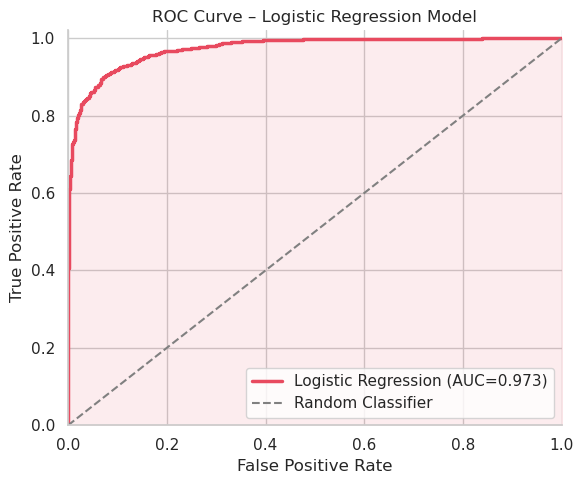

In [17]:
# Ensure visualizations are displayed inline in the Jupyter Notebook
%matplotlib inline

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming y_test and y_proba are already defined
# Chart 5: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)  # Calculate the AUC

# Create the ROC curve plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=ACCENT, linewidth=2.5, label=f'Logistic Regression (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color=ACCENT)

# Set labels and title
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve – Logistic Regression Model', xlim=(0, 1), ylim=(0, 1.02))
ax.legend(fontsize=11)

plt.tight_layout()

# Display the plot inline
plt.show()

# Optional: Uncomment to save the figure
# plt.savefig(f"{OUTPUT_DIR}chart_roc.png", dpi=150, bbox_inches='tight'); plt.close()

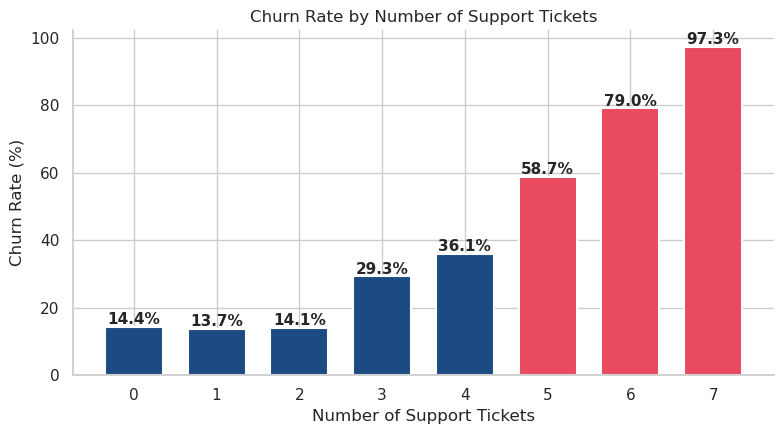

In [18]:
# Ensure visualizations are displayed inline in the Jupyter Notebook
%matplotlib inline

import matplotlib.pyplot as plt

# Assuming df is already defined and contains the relevant data
# Chart 6: Churn by Support Tickets
tickets_churn = df.groupby(df['number_of_support_tickets'].clip(0, 7))['churn'].mean() * 100

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 4.5))
bar_colors = [PRIMARY if v < 50 else ACCENT for v in tickets_churn.values]
bars = ax.bar(tickets_churn.index, tickets_churn.values,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.7)

# Add text annotations for each bar
for bar, val in zip(bars, tickets_churn.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Set labels and title
ax.set(xlabel='Number of Support Tickets', ylabel='Churn Rate (%)',
       title='Churn Rate by Number of Support Tickets', xticks=tickets_churn.index)

plt.tight_layout()

# Display the plot inline
plt.show()

# Optional: Uncomment to save the figure
# plt.savefig(f"{OUTPUT_DIR}chart_churn_by_tickets.png", dpi=150, bbox_inches='tight'); plt.close()

In [19]:
# ════════════════════════════════════════════════════════════════════════
# 6. SUMMARY STATISTICS
# ════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("KEY SUMMARY STATISTICS")
print("=" * 60)
print(f"\nAvg Satisfaction Score (Retained vs Churned):")
print(df.groupby('churn')['satisfaction_score'].mean().rename({0:'Retained',1:'Churned'}))
print(f"\nAvg Support Tickets (Retained vs Churned):")
print(df.groupby('churn')['number_of_support_tickets'].mean().rename({0:'Retained',1:'Churned'}))
print(f"\nAvg Days Since Login (Retained vs Churned):")
print(df.groupby('churn')['last_login_days_ago'].mean().rename({0:'Retained',1:'Churned'}))
print(f"\nAvg Tenure (Retained vs Churned):")
print(df.groupby('churn')['tenure_months'].mean().rename({0:'Retained',1:'Churned'}))
print(f"\nChurn Rate by Contract Type:")
print(df.groupby('contract_type')['churn'].mean().apply(lambda x: f'{x*100:.1f}%'))
print(f"\nChurn Rate by Region:")
print(df.groupby('region')['churn'].mean().apply(lambda x: f'{x*100:.1f}%'))


KEY SUMMARY STATISTICS

Avg Satisfaction Score (Retained vs Churned):
churn
Retained    3.878144
Churned     2.329709
Name: satisfaction_score, dtype: float64

Avg Support Tickets (Retained vs Churned):
churn
Retained    1.919154
Churned     5.080284
Name: number_of_support_tickets, dtype: float64

Avg Days Since Login (Retained vs Churned):
churn
Retained    12.546540
Churned     41.404976
Name: last_login_days_ago, dtype: float64

Avg Tenure (Retained vs Churned):
churn
Retained    19.133601
Churned     13.848840
Name: tenure_months, dtype: float64

Churn Rate by Contract Type:
contract_type
monthly    47.7%
yearly     19.7%
Name: churn, dtype: object

Churn Rate by Region:
region
Asia Pacific     31.0%
Europe           32.0%
Latin America    32.5%
Middle East      32.7%
North America    32.0%
Name: churn, dtype: object
